In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Step 1: Generate Skewed Data with Outliers
We will generate right-skewed data (e.g., income distribution) and add outliers.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate right-skewed data (e.g., income)
data = np.random.exponential(scale=50000, size=500).round(2)  # Exponential distribution
outliers = np.array([300000, 350000, 400000, 450000, 500000])  # Extreme values
data_with_outliers = np.concatenate([data, outliers])

# Convert to DataFrame
df = pd.DataFrame(data_with_outliers, columns=["income"])

print(df.sample(10))

       income
40    6507.61
107  70437.46
57   10906.73
152   7826.54
495  21797.68
308  79282.70
70   73974.19
360  24565.03
155  13857.24
260  47726.54


In [4]:
df.describe()

,income
count,505.000000
mean,53678.672238
std,59996.926604
min,253.720000
25%,13857.240000
50%,36524.770000
75%,71694.380000
max,500000.000000


# Step 2: Visualizing Outliers
We use boxplots and KDE plots to observe skewness and outliers.

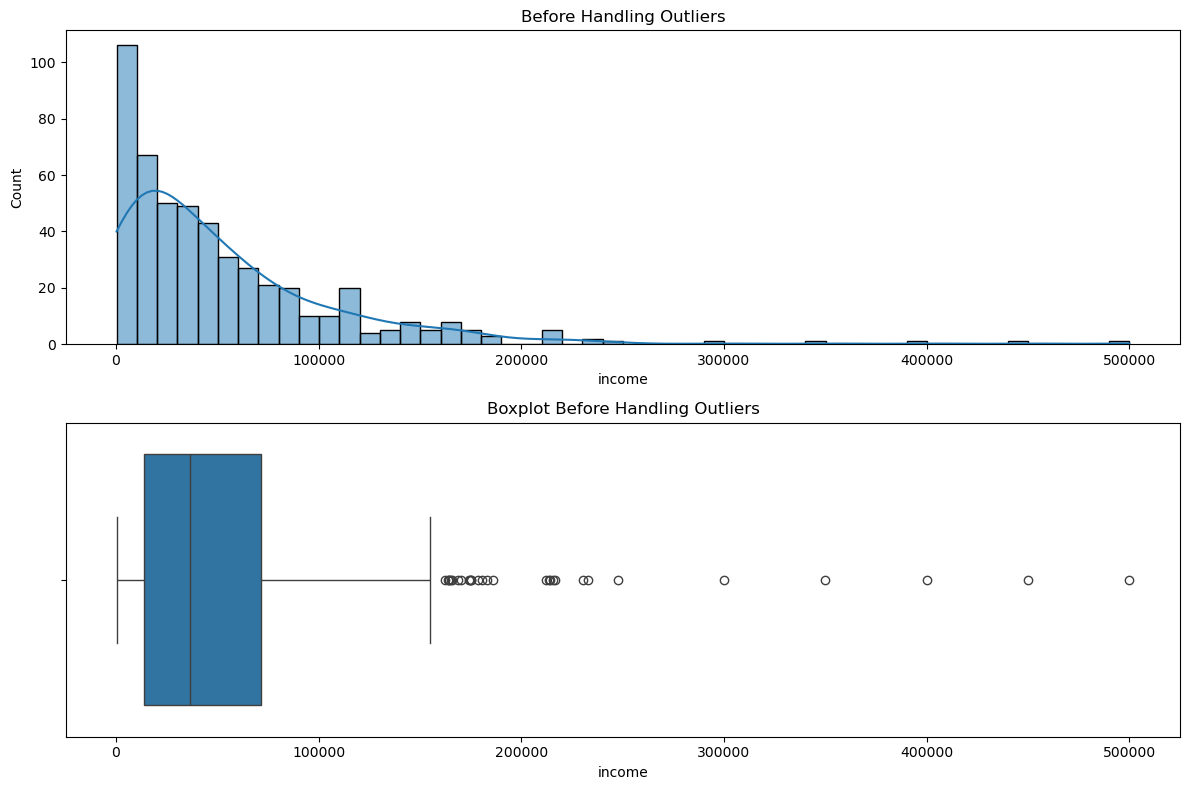

In [3]:

plt.figure(figsize=(12, 8))

# KDE / Histogram plot (TOP)
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st plot
sns.histplot(df["income"], kde=True, bins=50)
plt.title("Before Handling Outliers")

# Boxplot (BOTTOM)
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd plot
sns.boxplot(x=df["income"])
plt.title("Boxplot Before Handling Outliers")

# Adjust spacing
plt.tight_layout()

plt.show()


### Observations:

The long tail in the KDE plot confirms right-skewed data.

The boxplot shows extreme values (outliers).

# Step 3: Detect Outliers Using IQR Method
Interquartile Range (IQR) is a common method for detecting outliers.

In [5]:
# Compute IQR
Q1 = df["income"].quantile(0.25)
Q3 = df["income"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR # min
upper_bound = Q3 + 1.5 * IQR # max

# Find outliers
mask = (df["income"] < lower_bound) | (df["income"] > upper_bound)
outliers = df[mask]
print(f"Number of Outliers: {len(outliers)}")

Number of Outliers: 29


In [7]:
outliers

,income
11,175177.87
34,168531.52
50,174640.36
69,216707.32
139,178389.91
140,164100.49
154,212201.85
226,180615.47
247,170042.10
248,165686.77


In [6]:
Q1, Q3, lower_bound, upper_bound

(13857.24, 71694.38, -72898.47, 158450.09000000003)

## Observation:
We identify several high-income outliers.

# Step 4: Handling Outliers (Capping Method)
Instead of removing outliers, we can cap them at a threshold to preserve data.

AKA - **Winsorization**

In [8]:
# Cap values at upper bound
df_capped = df.copy()
# df_capped["income"] = np.where(df_capped["income"] > upper_bound, upper_bound, df_capped["income"])

# Or use clip function
df_capped['income'] = df_capped['income'].clip(lower=lower_bound, upper=upper_bound)

# Step 5: Compare Before & After Handling Outliers

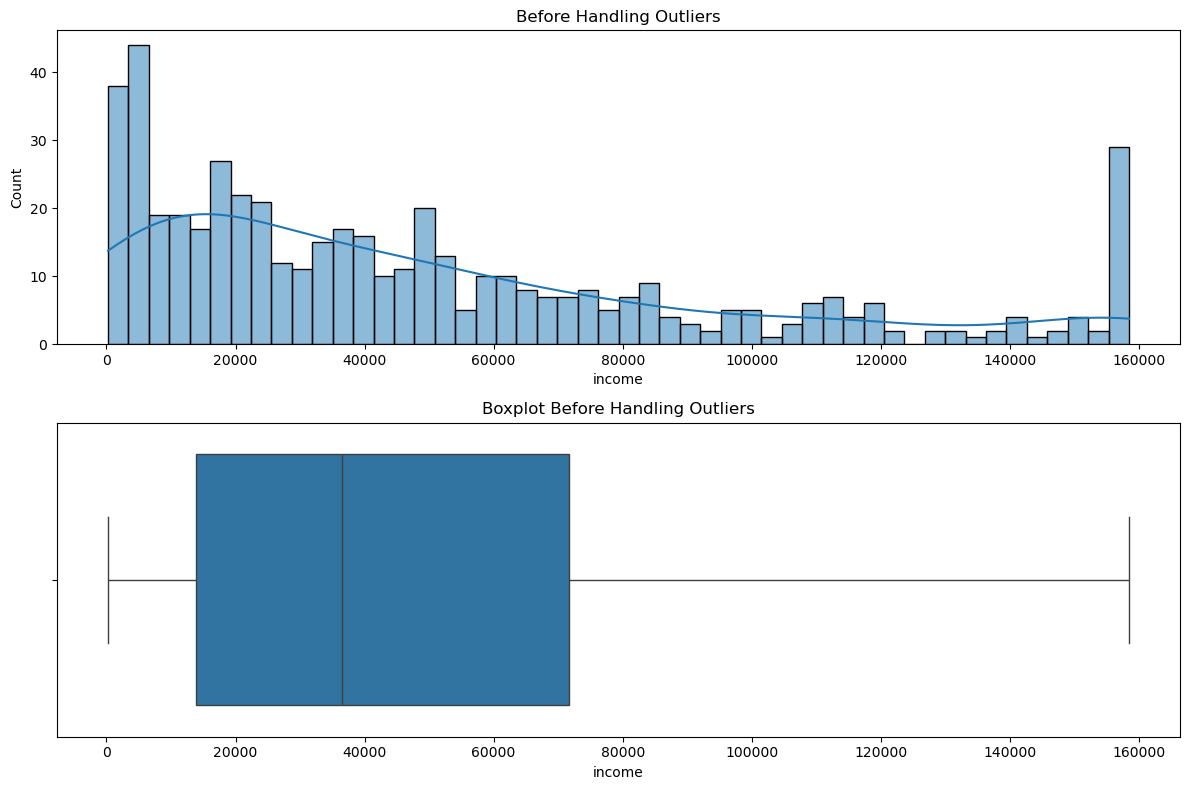

In [9]:

plt.figure(figsize=(12, 8))

# KDE / Histogram plot (TOP)
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st plot
sns.histplot(df_capped["income"], kde=True, bins=50)
plt.title("Before Handling Outliers")

# Boxplot (BOTTOM)
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd plot
sns.boxplot(x=df_capped["income"])
plt.title("Boxplot Before Handling Outliers")

# Adjust spacing
plt.tight_layout()

plt.show()


# Step 6: Analyzing Changes in Dataset Characteristics

In [8]:
# Compare statistics before and after
summary_before = df["income"].describe()
summary_after = df_capped["income"].describe()

# Compute skewness before and after
skew_before = skew(df["income"])
skew_after = skew(df_capped["income"])

print("Summary Before Handling Outliers:")
print(summary_before)
print("\nSummary After Handling Outliers:")
print(summary_after)

print(f"\nSkewness Before: {skew_before:.2f}")
print(f"Skewness After: {skew_after:.2f}")


Summary Before Handling Outliers:
count       505.000000
mean      53678.672234
std       59996.926492
min         253.721853
25%       13857.240678
50%       36524.766249
75%       71694.381312
max      500000.000000
Name: income, dtype: float64

Summary After Handling Outliers:
count       505.000000
mean      49836.889822
std       45541.037242
min         253.721853
25%       13857.240678
50%       36524.766249
75%       71694.381312
max      158450.092263
Name: income, dtype: float64

Skewness Before: 2.80
Skewness After: 1.05


# Observations:

- **Mean Decreases**: Since outliers were large values, removing them lowers the mean.

- **Standard Deviation Decreases**: The dataset becomes less spread out.

- **Skewness Reduces**: The right-skewed distribution becomes closer to normal.